## Ejemplo PCA
<div style="border-style:groove;border-width:thin;padding:10px">
En este ejercicio vamos a ver un ejemeplo de Principal Component Analysis. Recordamos que el objetivo de este algoritmo es reducir el número de dimensiones para hacer más simple el problema sin perder información.
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
Para ilustrar esta técnica vamos a utilizar las imágenes de números de MNIST. Tiene 784 entradas. ¿Hay que usarlas todas? Ya habíamos hablado de que los bordes son siempre blancos y de que las imágenes están en el centro. Además, tienen siempre los mismos tonos y los píxeles contiguos tienen un tono similar. Por todas estas razones es probable que se pueda reducir el número de dimensiones.
    </div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

<div style="border-style:groove;border-width:thin;padding:10px">
En primer lugar vamos a importar los datos de MNIST.
    </div>

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

/home/loren/anaconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


(70000, 784)
(70000,)


<div style="border-style:groove;border-width:thin;padding:10px">
Generamos los conjutos de training y de test.
    </div>

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

<div style="border-style:groove;border-width:thin;padding:10px">
Veamos que pinta tienen las imágenes del dataset.
    </div>

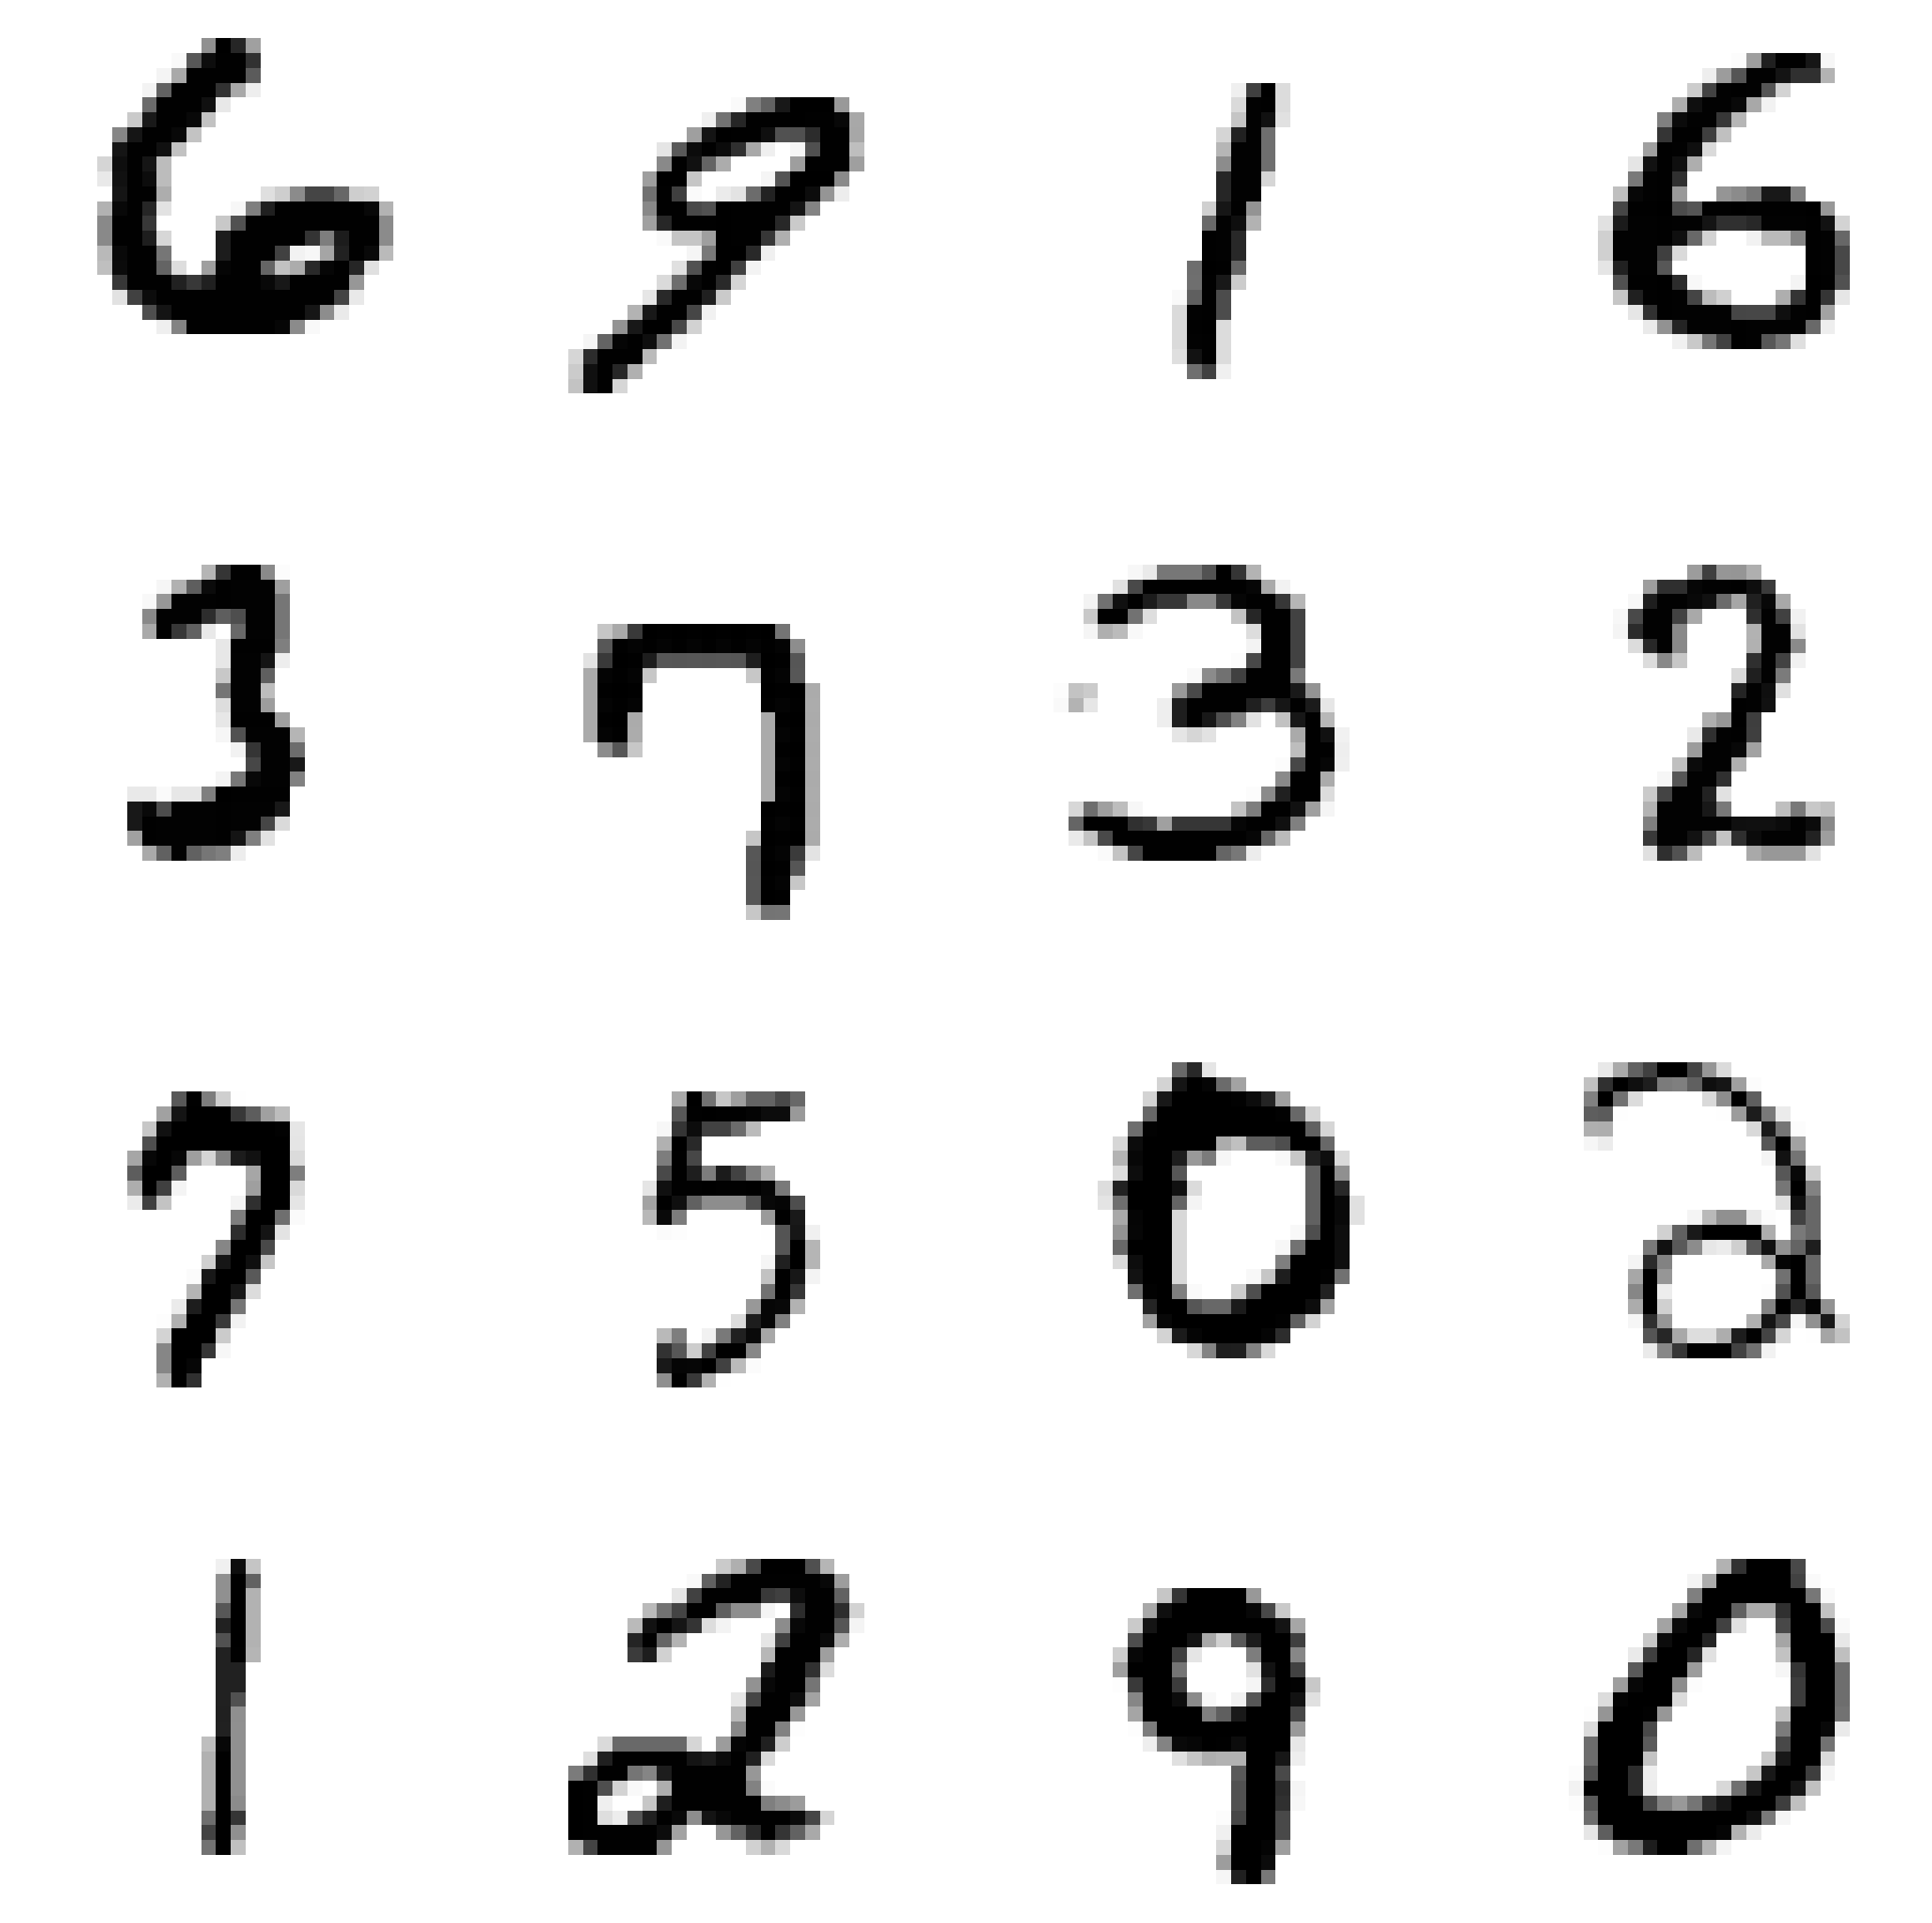

In [4]:
plt.figure(figsize=(28,28))
for i in range(16):
    some_digit = X_train.iloc[[i]].values
    some_digit_image = some_digit.reshape(28, 28)
    plt.subplot(4,4,i+1)
    plt.imshow(some_digit_image, cmap="binary")
    plt.axis("off")
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
Ahora vamos a reducir las dimensiones del conjunto de training, pero... ¿Cuántas entradas tenemos que usar? ¿Y cuales? Por suerte, PCA nos soluciona eso. Primero vamos a hacer un análisis para ver cuantas entradas necesitamos.
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
1. Importa PCA que está en el paquete decomposition de sklearn. Crea el objeto PCA sin parámetros. Entrena el análisis con los datos de entrenamiento X_train y su método fit. 
    </div>

In [4]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train)


PCA()

<div style="border-style:groove;border-width:thin;padding:10px">
2. Pinta el atributo explained_variance_ratio_ del objeto PCA. Ese atributo devuelve una lista ordenada del porcentaje de varianza que tiene cada componente del total de varianza del conjunto. Es decir, entre todas las varianzas de las 784 componentes sumarán 1. Las primeras son las que más porcentaje de varianza contienen. ¿Con cuantas nos quedamos? Usa la función cumsum de numpy para hacer la suma acumulativa de toda la lista. Esta función te va a devolver una lista así: [V0, V0+V1, V0+V1+V2, V0+V1+V2+V3...]. Guarda el resultado en una variable.
    </div>

In [9]:
print(pca.explained_variance_ratio_)

[9.74953595e-02 7.15549253e-02 6.17307253e-02 5.42096456e-02
 4.86358819e-02 4.30386241e-02 3.29021017e-02 2.89121559e-02
 2.76291368e-02 2.33756430e-02 2.11129675e-02 2.03424308e-02
 1.69924583e-02 1.69482780e-02 1.57613009e-02 1.48442789e-02
 1.32635745e-02 1.27335310e-02 1.18915949e-02 1.15968801e-02
 1.06660812e-02 1.00733599e-02 9.57071311e-03 9.09349195e-03
 8.89264249e-03 8.39514299e-03 8.11784318e-03 7.88107394e-03
 7.36445962e-03 6.91829515e-03 6.54516548e-03 6.42784496e-03
 6.01220800e-03 5.85327408e-03 5.70122308e-03 5.42591855e-03
 5.02238092e-03 4.89210473e-03 4.81485298e-03 4.65447475e-03
 4.53262728e-03 4.45492761e-03 4.19143680e-03 3.96706391e-03
 3.83409759e-03 3.75093952e-03 3.62312867e-03 3.48891587e-03
 3.38416276e-03 3.19981662e-03 3.15416297e-03 3.07640592e-03
 2.95371154e-03 2.87000564e-03 2.81513838e-03 2.69525259e-03
 2.66935505e-03 2.55465495e-03 2.53285229e-03 2.45519827e-03
 2.39906870e-03 2.37808595e-03 2.28961192e-03 2.21087419e-03
 2.12799574e-03 2.048403

In [10]:
cumsum = np.cumsum(pca.explained_variance_ratio_)

In [11]:
print(cumsum)

[0.09749536 0.16905028 0.23078101 0.28499066 0.33362654 0.37666516
 0.40956726 0.43847942 0.46610856 0.4894842  0.51059717 0.5309396
 0.54793206 0.56488033 0.58064163 0.59548591 0.60874949 0.62148302
 0.63337461 0.64497149 0.65563758 0.66571094 0.67528165 0.68437514
 0.69326778 0.70166293 0.70978077 0.71766184 0.7250263  0.7319446
 0.73848976 0.74491761 0.75092982 0.75678309 0.76248431 0.76791023
 0.77293261 0.77782472 0.78263957 0.78729405 0.79182667 0.7962816
 0.80047304 0.8044401  0.8082742  0.81202514 0.81564827 0.81913718
 0.82252135 0.82572116 0.82887532 0.83195173 0.83490544 0.83777545
 0.84059059 0.84328584 0.84595519 0.84850985 0.8510427  0.8534979
 0.85589697 0.85827505 0.86056467 0.86277554 0.86490354 0.86695194
 0.8689781  0.87092988 0.87283715 0.87472346 0.87658888 0.8783803
 0.88014167 0.88187363 0.88351701 0.88514778 0.88675776 0.88829827
 0.88976194 0.89118043 0.89259484 0.89399466 0.8953923  0.89673683
 0.89806012 0.89937205 0.90065456 0.90190755 0.90313379 0.90433402


<div style="border-style:groove;border-width:thin;padding:10px">
3. Haz una gráfica con la variable resultante en el eje Y y el número de dimensiones en el eje X. Discutid el resultado.
    </div>

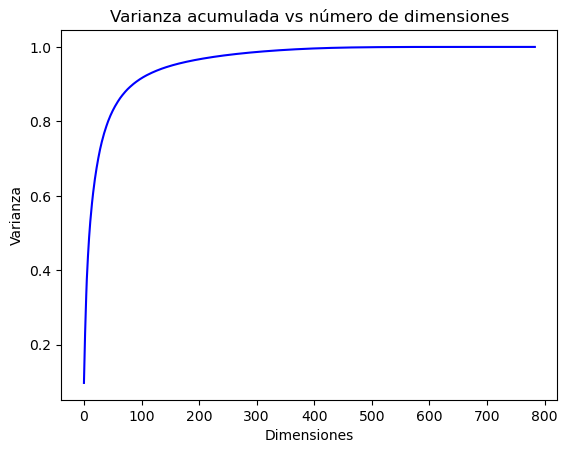

In [12]:
plt.plot(range(len(cumsum)),cumsum,color='blue')
plt.title("Varianza acumulada vs número de dimensiones")
plt.xlabel('Dimensiones')
plt.ylabel('Varianza')
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
4. Ahora vamos a sacar el número de dimensiones con el que se conserva el 95% de la varianza. Para ello puedes usar la siguiente función: "np.argmax(cumsum >= 0.95) + 1". Ponemos +1 porque recordamos que en una lista el primer elemento es el 0.
    </div>

In [27]:
d = np.argmax(cumsum >= 0.99999) + 1
print(d)

635


<div style="border-style:groove;border-width:thin;padding:10px">
    5. Ahora que conoces el número de dimensiones que conservan el 95% de la varianza vuelve a crear un objeto PCA pero esta vez con el parámetro n_components=N. Usa el método fit para entrenar el algoritmo con X_train. Usa el método transform para transformar X_train en un conjunto de 154 dimensiones. 
    </div>

In [5]:
#pca = PCA(n_components=d)
#NOTA: ESTO LO HEMOS HECHO PARA ENTENDER PCA. A PARTIR DE AHORA LO HAREMOS ASÍ:
pca = PCA(n_components=0.95)
#Si en n_components metes un float menor que uno, es directamente la varianza que quieres. Todo lo de arriba no
# habría que hacerlo.
pca.fit(X_train)
X_reduced = pca.transform(X_train)
X_recovered = pca.inverse_transform(X_reduced)
X_reduced.shape

#Esto lo hemos hecho para ver paso a paso lo que hace el algoritmo, se podría hacer más rápido metiendo 
# en n_components un valor float entre 0.0 y 1.0. 

(52500, 154)

In [6]:
X_test_reduced = pca.transform(X_test)

<div style="border-style:groove;border-width:thin;padding:10px">
6. Entre todos pintad algunas entradas del conjunto resultante. ¿Se parece al orginal?
    </div>

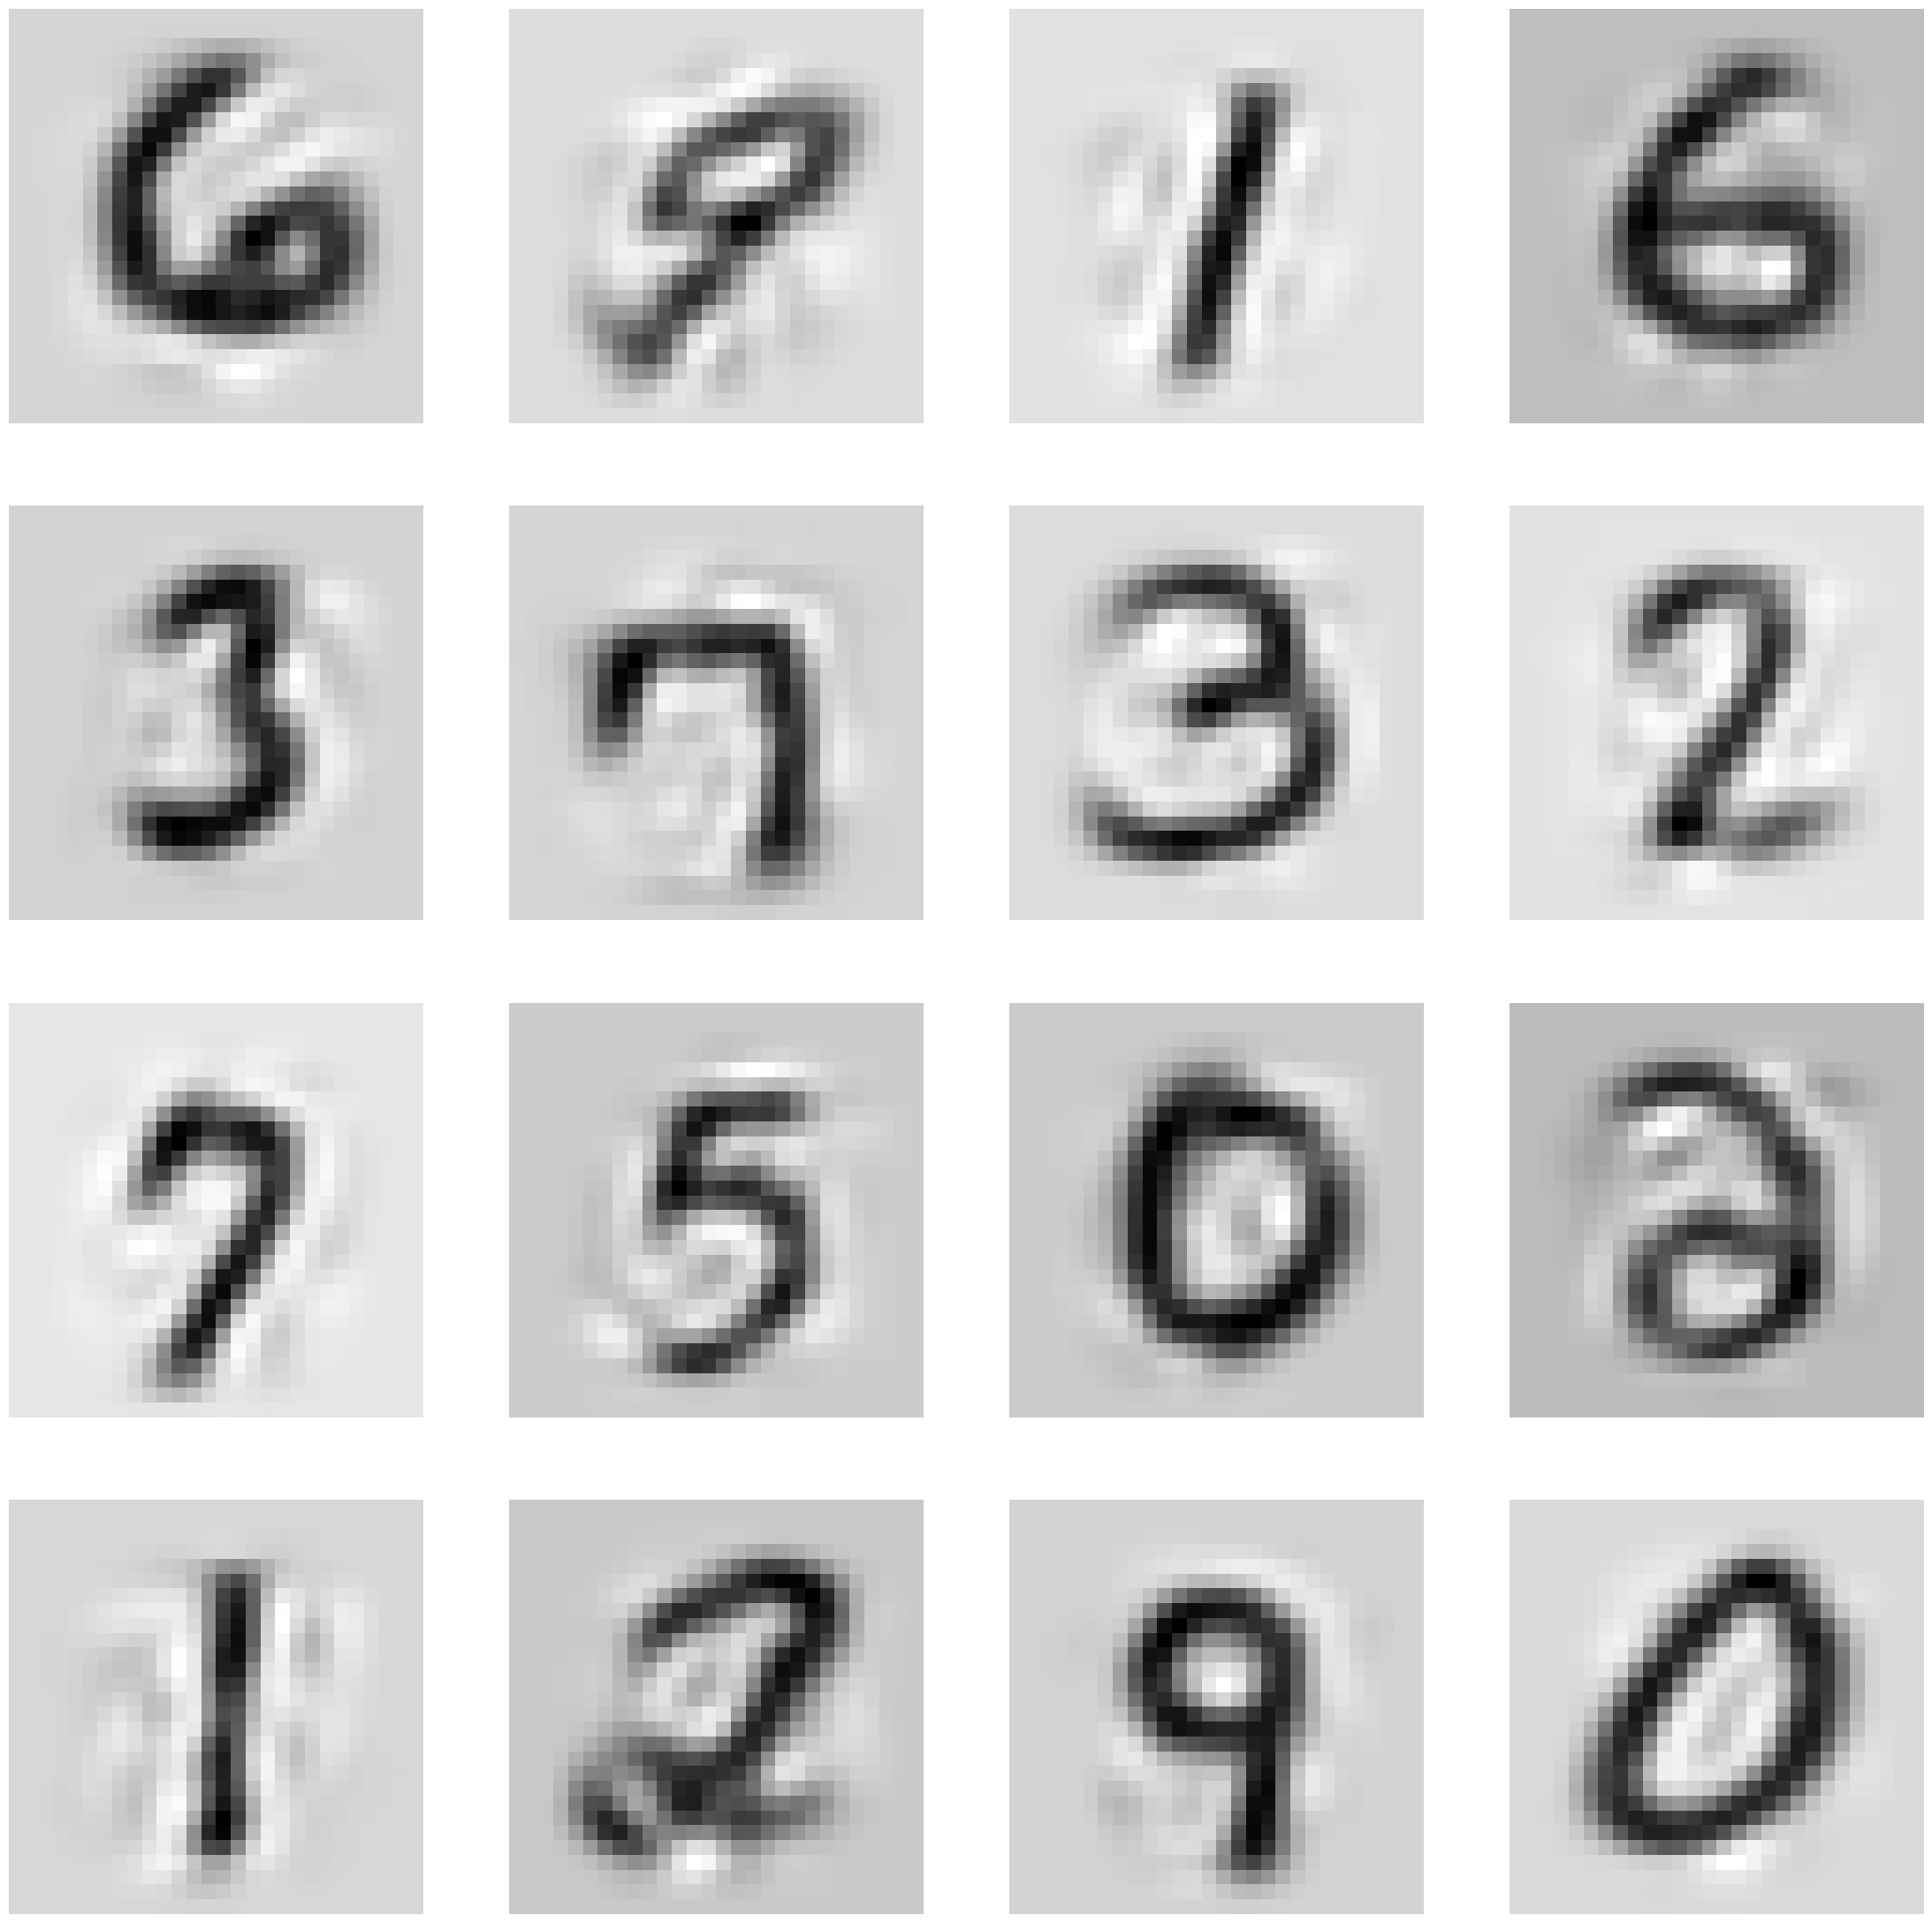

In [ ]:
plt.figure(figsize=(28,28))
for i in range(16):
    some_digit = X_recovered[i]
    some_digit_image = some_digit.reshape(28, 28)
    plt.subplot(4,4,i+1)
    plt.imshow(some_digit_image, cmap="binary")
    plt.axis("off")
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
7. Resuelve el ejercicio con SVC como hicimos en su día pero con el conjunto reducido. Usa X_test para evaluar el resultado.
    </div>

In [7]:
from sklearn.svm import SVC
svc2 = SVC(kernel='poly',C=5)
svc2.fit(X_reduced,y_train)
y_pred = svc2.predict(X_test_reduced)

In [8]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr) 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1715
           1       0.99      1.00      0.99      1971
           2       0.98      0.98      0.98      1786
           3       0.99      0.98      0.98      1763
           4       0.98      0.99      0.98      1676
           5       0.98      0.98      0.98      1593
           6       0.99      0.99      0.99      1710
           7       0.98      0.98      0.98      1837
           8       0.97      0.98      0.98      1713
           9       0.98      0.97      0.97      1736

    accuracy                           0.98     17500
   macro avg       0.98      0.98      0.98     17500
weighted avg       0.98      0.98      0.98     17500

